# UMAP photo mosaic — walkthrough

Every step the command-line tools take, one cell at a time, on a public dataset.

1. Get an embedding and a set of images.
2. Hand every image a square of the scatter, and hand the points out by proximity.
3. Choose how it is drawn: painted dots, or an image overlay.
4. Sweep the two knobs the viewer exposes — how much image, and how big the dots.
5. Run the tools to produce the interactive page and the poster.

Run `python scripts/fetch_example.py --dataset mnist --images-from emoji` first, or
change `EXAMPLE` below to `"digits"` for the bundled dataset that needs no download.

The points are handwritten digits and the pictures are emoji. They have nothing to
do with each other, which is the normal case: you have data, and you have pictures
you want the data to be made of. `--images-from` also takes `faces` (AI-generated
portraits, cut out with GrabCut), `cartoon` and `anime`; swap the word and every
cell below re-runs on the same map with different pictures.

In [1]:
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
from PIL import Image

ROOT = Path.cwd() if (Path.cwd() / "scatter_mosaic").is_dir() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

from scatter_mosaic import images as img
from scatter_mosaic.dataset import load_embedding
from scatter_mosaic.layout import normalize_isotropic
from scatter_mosaic.painting import blend_with_region, paint_patches
from scatter_mosaic.placement import allocate_faces, assign_regions
from scatter_mosaic.theme import use_theme

EXAMPLE = "mnist-emoji"                # or mnist-faces, mnist-cartoon, mnist-anime
DATA = ROOT / "examples" / EXAMPLE
THEME = use_theme("light")             # "dark" swaps the palette and the chrome

plt.rcParams.update({
    "figure.facecolor": THEME["background"], "axes.facecolor": THEME["background"],
    "savefig.facecolor": THEME["background"], "text.color": THEME["ink"],
    "axes.edgecolor": THEME["line"], "xtick.color": THEME["muted"],
    "ytick.color": THEME["muted"], "figure.dpi": 110,
})
COLORS = np.array(THEME["palette"])
PAGE = tuple(bytes.fromhex(THEME["background"].lstrip("#")))
print(ROOT, "|", DATA)

C:\Codes\UMAP-photo-to-mosaic | C:\Codes\UMAP-photo-to-mosaic\examples\mnist-emoji


## 1. The inputs

Two things: a CSV with two coordinate columns, and a folder of images. The loader
guesses which columns are which (`x`/`y`, `UMAP1`/`UMAP2`, `tsne_1`/`tsne_2`, …)
and carries everything else through to the tooltip.

Nothing here is specific to a dataset — swap in your own CSV and your own pictures.

40,000 points · 10 images · embedding.csv · x/y


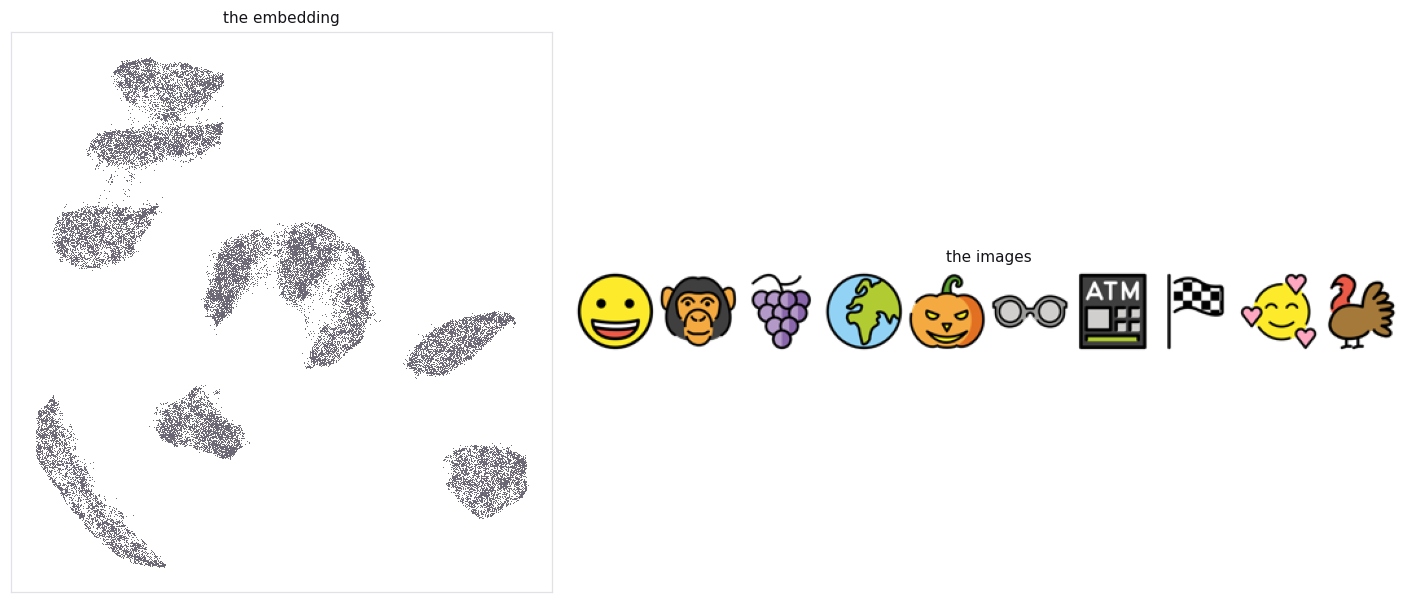

In [2]:
data = load_embedding(DATA / "embedding.csv")
catalogue = img.listing(DATA / "images")
tiles = [img.load(DATA / "images" / item["filename"], keep_alpha=True) for item in catalogue]
print(f"{len(data):,} points · {len(catalogue)} images · {data.source}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.4), gridspec_kw={"width_ratios": [2, 3]})
axes[0].scatter(data.x, data.y, c=THEME["muted"], s=0.4, linewidths=0, rasterized=True)
axes[0].set_aspect("equal"); axes[0].set_xticks([]); axes[0].set_yticks([])
axes[0].set_title("the embedding", fontsize=10)
strip = np.hstack([np.asarray(t.convert("RGBA").resize((64, 64))) for t in tiles[:10]])
axes[1].set_facecolor(THEME["background"])
axes[1].imshow(strip); axes[1].set_axis_off(); axes[1].set_title("the images", fontsize=10)
fig.tight_layout()

## 2. Where each image goes

No clustering decides this. `allocate_faces` treats the cloud as one canvas and
packs one equal square per image onto ground that can support it — `min_fill`
rejects holes, `min_density` rejects thin haze. Squares are taken best-supported
first, and one that can sit **flush** against another already placed gets an
`adjacency` bonus, so images tile into the roomy parts instead of each sitting
alone. A group stops growing at `group_cap`. If they will not all fit, the size
shrinks and it retries, so **every** image gets a home.

`min_fill` is the one worth tuning per dataset. A square cannot fill a curve, so
the default 0.85 shrinks every image until it fits inside one; 0.72 lets a square
overhang MNIST's rounded masses. Relax it too far and a face spills past its
island, which breaks the one promise the picture makes.

Points are then handed to their nearest image. The regions exist because the
images do, not the other way round.

10/10 placed at size 0.1094, packed into groups of [2, 1, 1, 1, 1, 1, 1, 1, 1]
regions hold 2,049 to 5,951 points


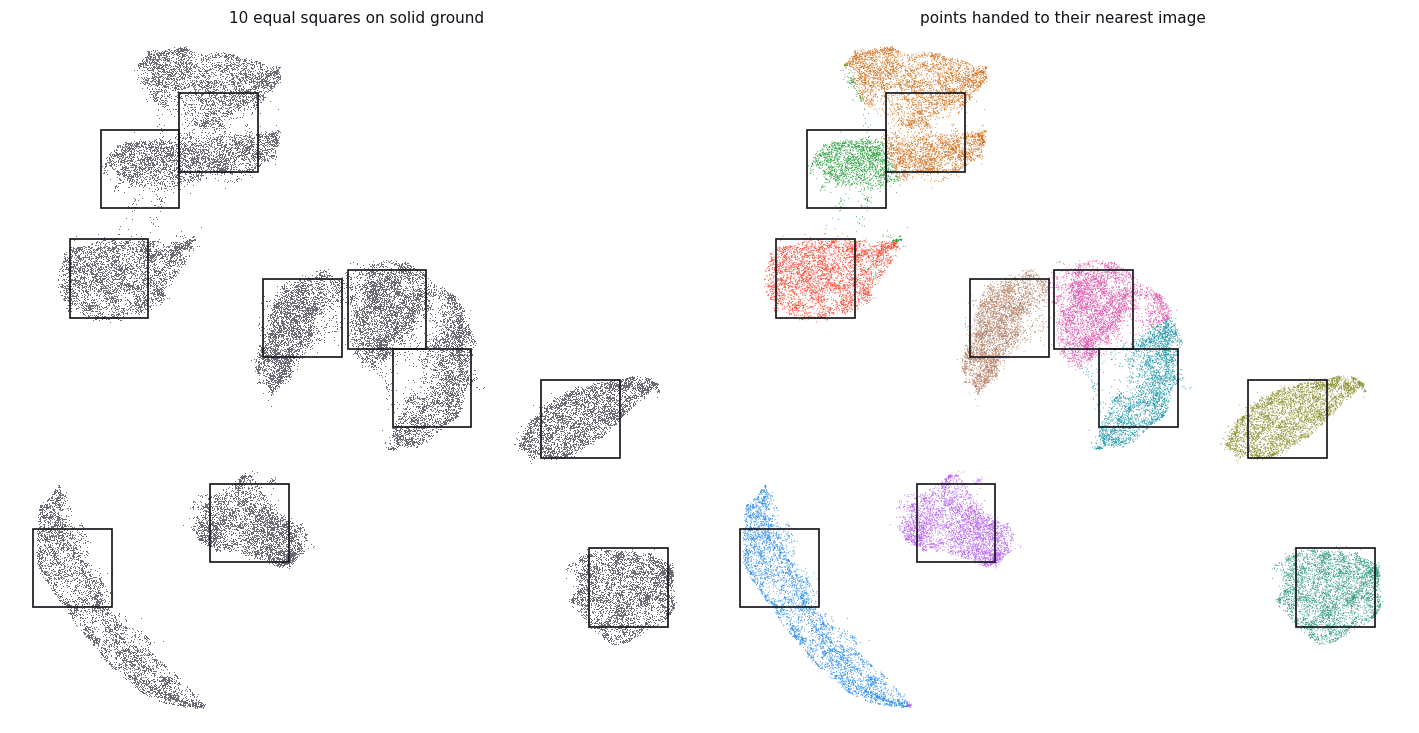

In [3]:
nx, ny = normalize_isotropic(data.x, data.y)
patches, used = allocate_faces(nx, ny, len(catalogue), size=0.14, min_fill=0.72,
                               min_density=0.55, adjacency=0.6, group_cap=4, seed=42)
labels = assign_regions(nx, ny, patches)
packed = pd.Series([p["group"] for p in patches]).value_counts().tolist()
spread = np.bincount(labels, minlength=len(patches))
print(f"{len(patches)}/{len(catalogue)} placed at size {used:.4f}, packed into groups of {packed}")
print(f"regions hold {spread.min():,} to {spread.max():,} points")


def frame(ax, title):
    ax.set_xlim(0.02, 0.98); ax.set_ylim(0.98, 0.02)
    ax.set_aspect("equal"); ax.set_axis_off(); ax.set_title(title, fontsize=10)


fig, axes = plt.subplots(1, 2, figsize=(13, 6.6))
axes[0].scatter(nx, ny, c=THEME["muted"], s=0.4, linewidths=0, rasterized=True)
axes[1].scatter(nx, ny, c=COLORS[labels % len(COLORS)], s=0.4, linewidths=0, rasterized=True)
for ax in axes:
    for patch in patches:
        x0, y0, x1, y1 = patch["box"]
        ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, ec=THEME["ink"], lw=1.1))
frame(axes[0], f"{len(patches)} equal squares on solid ground")
frame(axes[1], "points handed to their nearest image")
fig.tight_layout()

## 3. How it is drawn

**Overlay** puts the image on top of the dots. It reads as a picture, but it hides
the very thing it is drawn on.

**Paint** never draws an image. It samples the image at each point's own position
and gives that colour to that point's dot. Nothing is covered: every dot, wisp and
gap in the embedding survives, and the picture emerges from the scatter. Points
that land on removed background keep a faded region colour — and where the
image fades rather than stops, so does the share of dots that take its colour.

37.8% of points land on an image


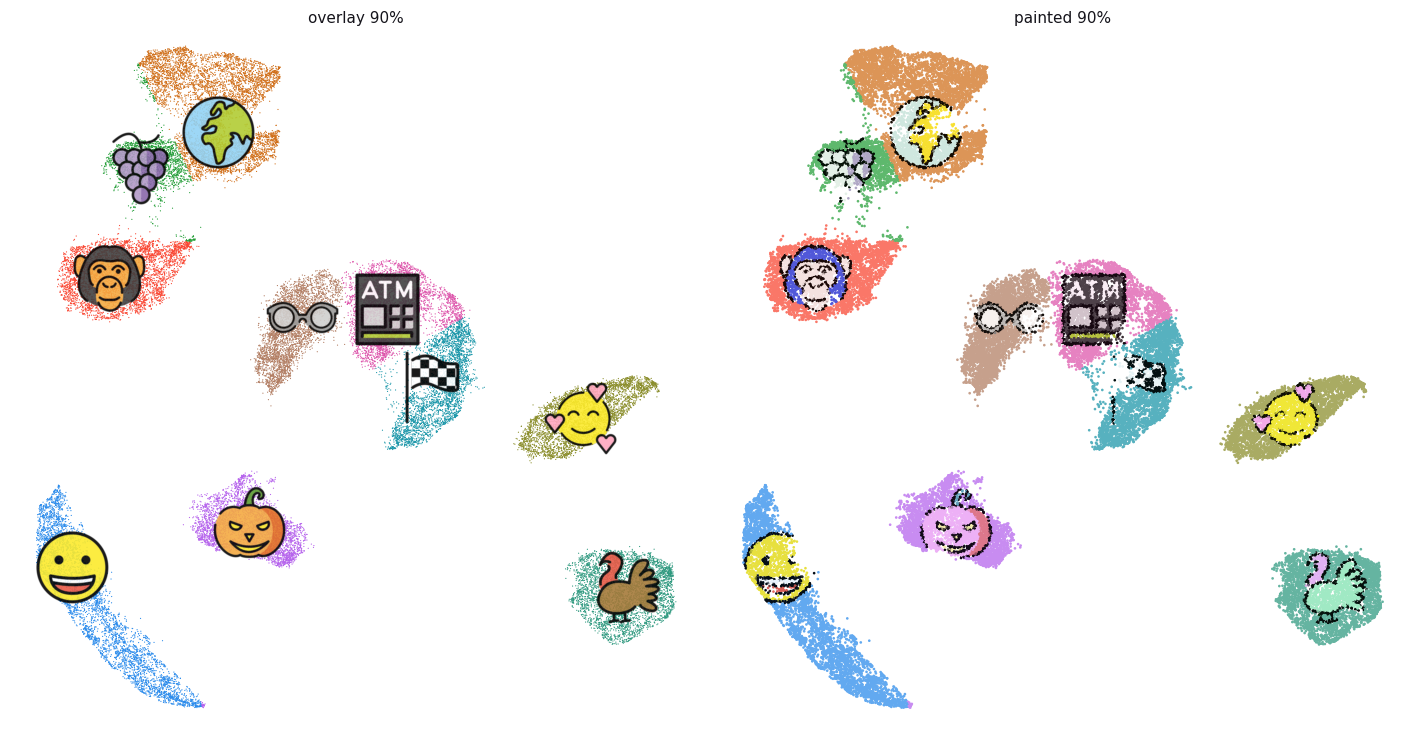

In [4]:
REGION_RGB = np.array([list(bytes.fromhex(c.lstrip("#"))) for c in COLORS[:len(patches)]], np.uint8)
sampled, on_subject = paint_patches(nx, ny, patches, tiles)
print(f"{on_subject.mean():.1%} of points land on an image")


def draw_paint(ax, amount, dots=3.0, ghost=None):
    painted = blend_with_region(sampled, on_subject, labels, REGION_RGB, amount,
                                THEME["ghost"]["scatter"] if ghost is None else ghost, PAGE)
    ax.scatter(nx, ny, c=painted / 255, s=dots, linewidths=0, rasterized=True)
    frame(ax, f"painted {amount:.0%}")


def draw_overlay(ax, amount):
    ax.scatter(nx, ny, c=COLORS[labels % len(COLORS)], s=0.6, linewidths=0, rasterized=True)
    for patch in patches:
        x0, y0, x1, y1 = patch["box"]
        ax.imshow(np.asarray(tiles[patch["region"]].convert("RGBA")), alpha=amount,
                  zorder=3, interpolation="bilinear", extent=(x0, x1, y1, y0))
    frame(ax, f"overlay {amount:.0%}")


fig, axes = plt.subplots(1, 2, figsize=(13, 6.6))
draw_overlay(axes[0], 0.9)
draw_paint(axes[1], THEME["photo_alpha"])
fig.tight_layout()

## 4. The two knobs the viewer exposes

**How much image** eases every point between its plain region colour and its image
colour. At 0 you are looking at the bare embedding.

**Dot size** trades reach for detail. Big dots make the picture read from across
the room but blur fine structure; small dots resolve more but let the page through.
Neither changes the *information* — that is fixed by how many points you have.

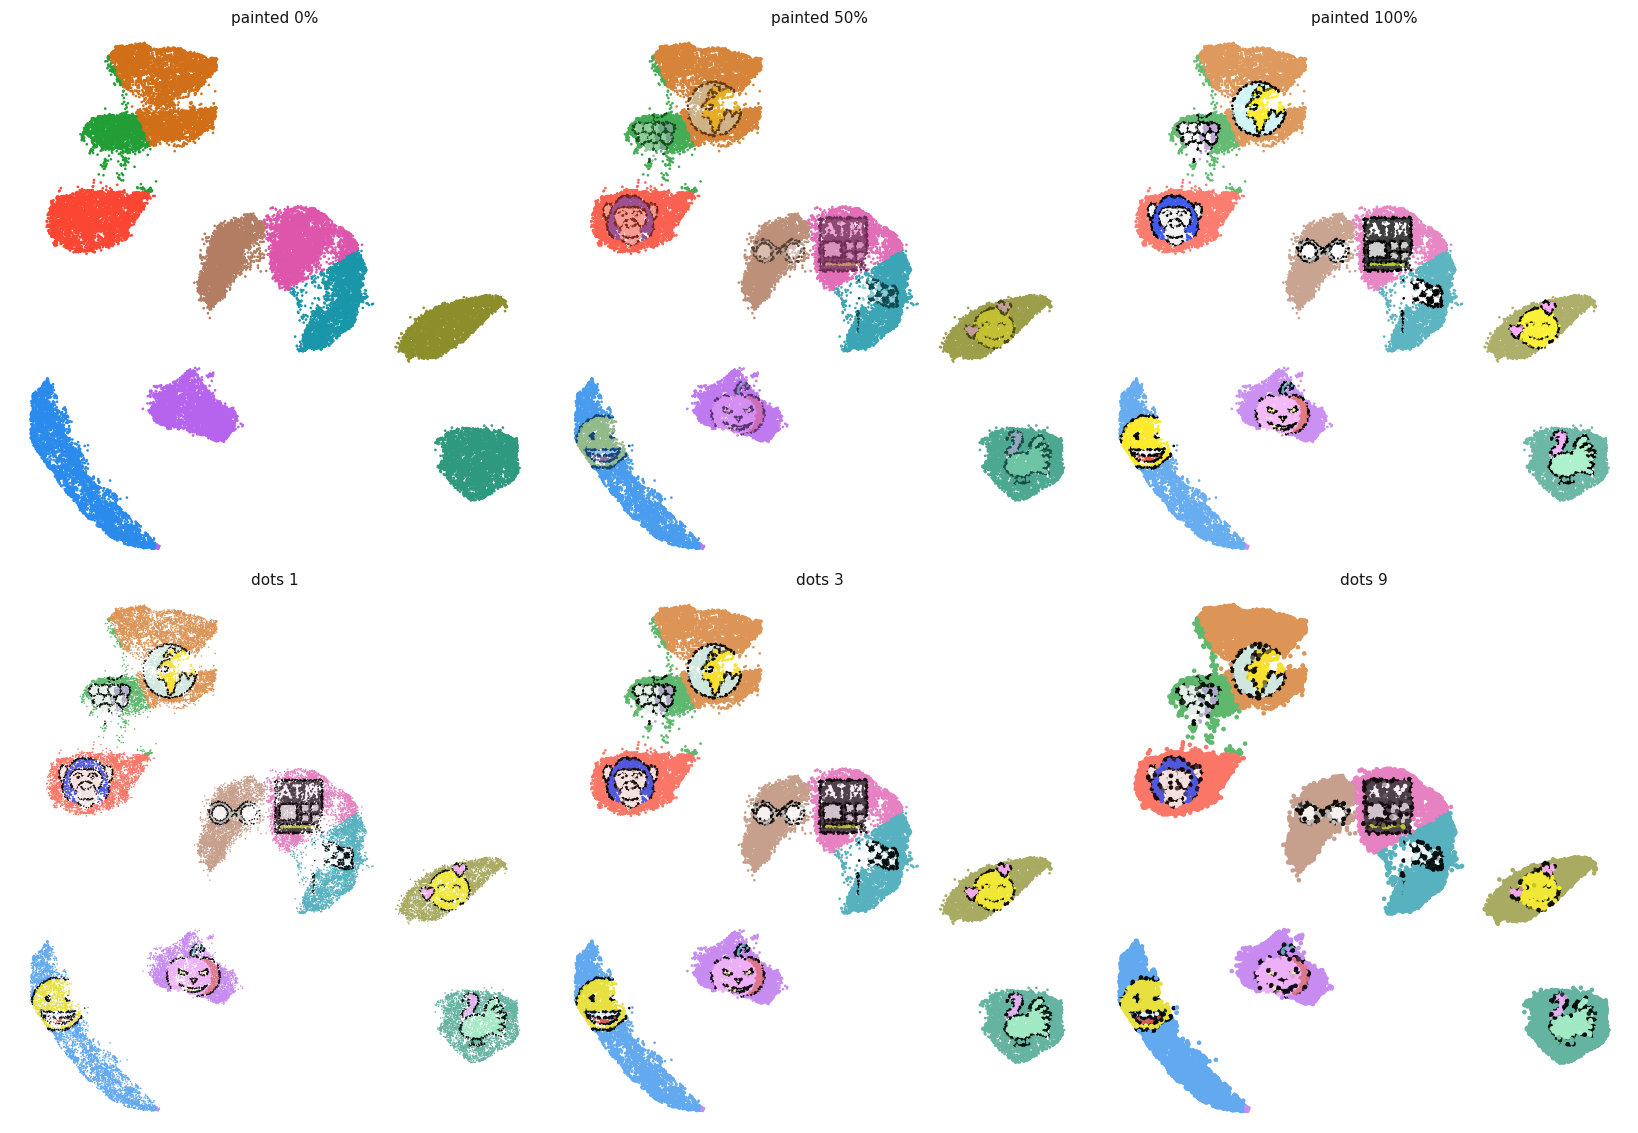

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10.5))
for ax, amount in zip(axes[0], (0.0, 0.5, 1.0)):
    draw_paint(ax, amount)
for ax, dots in zip(axes[1], (1.0, 3.0, 9.0)):
    draw_paint(ax, THEME["photo_alpha"], dots=dots)
    ax.set_title(f"dots {dots:g}", fontsize=10)
fig.tight_layout()

## 5. Produce the artwork

Same parameters, now through the tools. The page carries both themes and both
styles, so the theme toggle, the image slider and the dot-size slider all work
without rebuilding.

In [6]:
def run(script, *flags):
    result = subprocess.run([sys.executable, str(ROOT / "scripts" / script), *flags],
                            capture_output=True, text=True, cwd=ROOT)
    print(result.stdout.strip() or result.stderr.strip())
    result.check_returncode()


run("build_mosaic.py", "--embedding", str(DATA / "embedding.csv"), "--images", str(DATA / "images"),
    "--out", str(DATA / "mosaic"), "--face-size", "0.14", "--face-fill", "0.72")
run("build_poster.py", "--regions", str(DATA / "mosaic" / "regions.csv"), "--images", str(DATA / "images"),
    "--width", "2400", "--height", "1800")

Built C:\Codes\UMAP-photo-to-mosaic\examples\mnist-emoji\mosaic\mosaic.html  (1.9 MB)
Embedded 40,000 points, 10/10 images, 10 overlays, 473 paint swatches
Placement: 10 squares at 0.1094, packed [2, 1, 1, 1, 1, 1, 1, 1, 1], regions 2,049-5,951 points
Opens on theme=light style=paint; both switchable in the page


Images: 10 placed, from patches.json
Saved poster: C:\Codes\UMAP-photo-to-mosaic\examples\mnist-emoji\mosaic\poster.png
Saved preview: C:\Codes\UMAP-photo-to-mosaic\examples\mnist-emoji\mosaic\poster_preview.jpg
Placement: scatter · 10 square patches
Style: paint · morph 0.45 (limit 1.90) · photo 0.90 · spots on
Plot area 1183x1224 px of 2184x1224 available (layout aspect 0.97:1)
Images: 10 real, 0 placeholder


Interactive page: C:\Codes\UMAP-photo-to-mosaic\examples\mnist-emoji\mosaic\mosaic.html


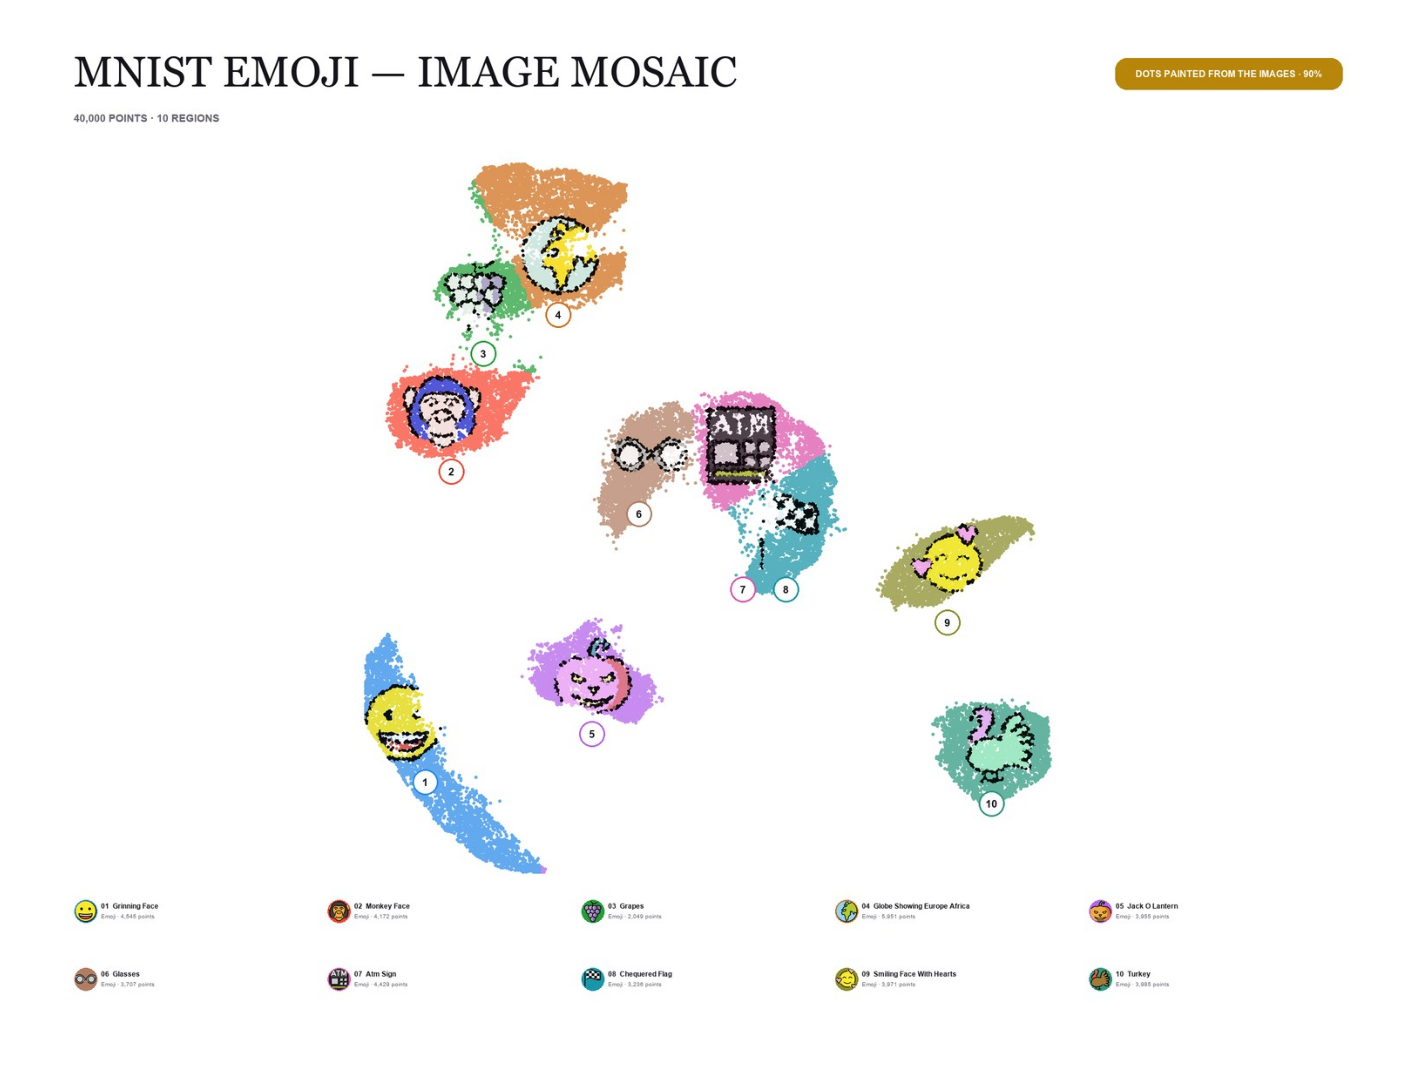

In [7]:
fig, ax = plt.subplots(figsize=(13, 9.8))
ax.imshow(Image.open(DATA / "mosaic" / "poster_preview.jpg"))
ax.set_axis_off(); fig.tight_layout()
print("Interactive page:", DATA / "mosaic" / "mosaic.html")